# NLP Task 4 – Fine-Tuning BERT on IMDB Movie Reviews
**Dataset:** IMDB Sentiment (Binary Classification)

---

## 1. Install Dependencies

In [2]:
# Install required packages (run once in Colab)
!pip install transformers datasets torch scikit-learn seaborn matplotlib -q

## 2. Imports

In [3]:
import torch
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Load & Explore Dataset

In [4]:
# Load IMDB from HuggingFace Datasets (same data as Kaggle IMDB)
raw_dataset = load_dataset("imdb")

# Convert to pandas for easier manipulation
train_df = pd.DataFrame(raw_dataset["train"])
test_df  = pd.DataFrame(raw_dataset["test"])

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train shape: (25000, 2)
Test shape : (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


In [6]:
# Quick look at class distribution
train_df["label"].value_counts()

,count
label,
0,12500
1,12500


## 4. Data Preprocessing

In [7]:
def clean_text(text):
    # Remove HTML tags (common in IMDB reviews)
    text = re.sub(r"<.*?>", " ", text)
    # Keep only letters and basic punctuation
    text = re.sub(r"[^a-zA-Z\s.,!?']", " ", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

# Check for missing values
print("Missing in train:", train_df["clean_text"].isna().sum())
print("Missing in test :", test_df["clean_text"].isna().sum())

print("\nSample cleaned review:")
print(train_df["clean_text"].iloc[0][:300])

Missing in train: 0
Missing in test : 0

Sample cleaned review:
I rented I AM CURIOUS YELLOW from my video store because of all the controversy that surrounded it when it was first released in . I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered controversial I really had to 


## 5. Data Splitting

In [8]:
# Use a subset for faster training (Colab GPU is limited – 5k samples is enough to demo)
# Remove the [:5000] slicing below if you want to train on the full 25k
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["clean_text"].tolist()[:5000],
    train_df["label"].tolist()[:5000],
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"].tolist()[:5000]
)

# Fixed held-out test set
test_texts  = test_df["clean_text"].tolist()[:1000]
test_labels = test_df["label"].tolist()[:1000]

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")

Train: 4250 | Val: 750 | Test: 1000


## 6. Tokenization

In [9]:
# Load bert-base-uncased tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 256  # BERT max is 512 – 256 covers most reviews & saves memory

def tokenize(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased


In [10]:
# Custom PyTorch Dataset wrapper
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        # Tokenize all texts upfront
        self.encodings = tokenize(texts)
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "token_type_ids": self.encodings["token_type_ids"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build datasets
train_dataset = IMDBDataset(train_texts, train_labels)
val_dataset   = IMDBDataset(val_texts,   val_labels)
test_dataset  = IMDBDataset(test_texts,  test_labels)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Batches – Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches – Train: 266 | Val: 47 | Test: 63


## 7. Helper Functions (Train / Evaluate)

In [11]:
def train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        # Clip gradients to avoid exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels         = batch["labels"]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


def print_metrics(preds, labels, title="Results"):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="weighted")
    rec  = recall_score(labels, preds, average="weighted")
    f1   = f1_score(labels, preds, average="weighted")
    print(f"\n{'='*45}")
    print(f"  {title}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'='*45}\n")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def plot_confusion_matrix(preds, labels, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

## 8. Experiment 1 – Freeze All BERT Layers, Train Only Classifier

In [12]:
# Load fresh model
model_exp1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp1.to(device)

# Freeze all BERT encoder weights – only the classifier head remains trainable
for name, param in model_exp1.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,538 / 109,483,778


In [13]:
EPOCHS = 3
LR     = 2e-5

optimizer_exp1 = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=LR)

# Linear warmup scheduler (bonus feature)
total_steps_exp1 = len(train_loader) * EPOCHS
scheduler_exp1   = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=int(0.1 * total_steps_exp1),
    num_training_steps=total_steps_exp1
)

print("Training Experiment 1 (Frozen BERT)...")
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1)
    val_preds, val_lbls = evaluate(model_exp1, val_loader)
    val_acc  = accuracy_score(val_lbls, val_preds)
    val_f1   = f1_score(val_lbls, val_preds, average="weighted")
    print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

Training Experiment 1 (Frozen BERT)...
  Epoch 1/3 | Loss: 0.1919 | Val Acc: 0.9987 | Val F1: 0.9993
  Epoch 2/3 | Loss: 0.0204 | Val Acc: 1.0000 | Val F1: 1.0000
  Epoch 3/3 | Loss: 0.0115 | Val Acc: 1.0000 | Val F1: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  Exp 1: Frozen BERT (Classifier Only)
  Accuracy  : 0.9980
  Precision : 1.0000
  Recall    : 0.9980
  F1 Score  : 0.9990



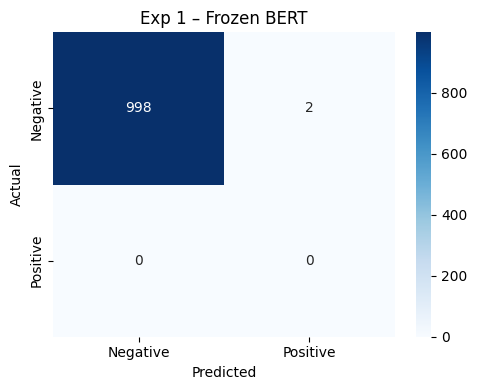

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1000
    Positive       0.00      0.00      0.00         0

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# Test evaluation for Experiment 1
test_preds_exp1, test_lbls_exp1 = evaluate(model_exp1, test_loader)
metrics_exp1 = print_metrics(test_preds_exp1, test_lbls_exp1, "Exp 1: Frozen BERT (Classifier Only)")
plot_confusion_matrix(test_preds_exp1, test_lbls_exp1, "Exp 1 – Frozen BERT")
print(classification_report(test_lbls_exp1, test_preds_exp1, target_names=["Negative", "Positive"]))

## 9. Experiment 2 – Fine-Tune Last 2 BERT Layers + Classifier

In [15]:
# Load a fresh copy of the model
model_exp2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp2.to(device)

# Freeze everything first
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze the last 2 transformer encoder layers (layer 10 and 11)
for layer in model_exp2.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

# Also unfreeze the pooler and classifier head
for param in model_exp2.bert.pooler.parameters():
    param.requires_grad = True
for param in model_exp2.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp2.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,767,874 / 109,483,778


In [17]:
optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=LR)

total_steps_exp2 = len(train_loader) * EPOCHS
scheduler_exp2   = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=int(0.1 * total_steps_exp2),
    num_training_steps=total_steps_exp2
)

# Early stopping tracker
best_val_f1    = 0.0
patience       = 2
patience_count = 0

print("Training Experiment 2 (Last 2 Layers + Classifier)...")
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2)
    val_preds, val_lbls = evaluate(model_exp2, val_loader)
    val_acc  = accuracy_score(val_lbls, val_preds)
    val_f1   = f1_score(val_lbls, val_preds, average="weighted")
    print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # Early stopping logic
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        # Save best model weights
        torch.save(model_exp2.state_dict(), "best_model_exp2.pt")
        print(f"    ✓ Best model saved (Val F1: {best_val_f1:.4f})")
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"    ⚡ Early stopping triggered at epoch {epoch+1}")
            break

# Load best weights before testing
model_exp2.load_state_dict(torch.load("best_model_exp2.pt"))

Training Experiment 2 (Last 2 Layers + Classifier)...
  Epoch 1/3 | Loss: 0.0001 | Val Acc: 1.0000 | Val F1: 1.0000
    ✓ Best model saved (Val F1: 1.0000)
  Epoch 2/3 | Loss: 0.0000 | Val Acc: 1.0000 | Val F1: 1.0000
  Epoch 3/3 | Loss: 0.0000 | Val Acc: 1.0000 | Val F1: 1.0000
    ⚡ Early stopping triggered at epoch 3


<All keys matched successfully>


  Exp 2: Last 2 Layers Fine-Tuned
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


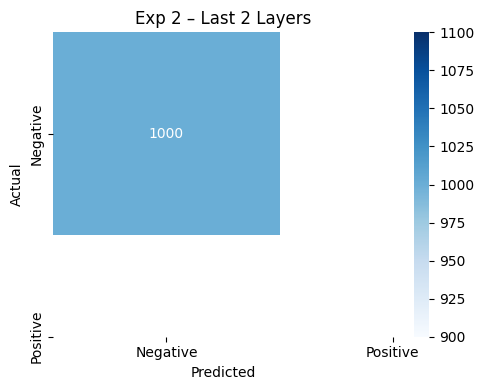

ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [18]:
# Test evaluation for Experiment 2
test_preds_exp2, test_lbls_exp2 = evaluate(model_exp2, test_loader)
metrics_exp2 = print_metrics(test_preds_exp2, test_lbls_exp2, "Exp 2: Last 2 Layers Fine-Tuned")
plot_confusion_matrix(test_preds_exp2, test_lbls_exp2, "Exp 2 – Last 2 Layers")
print(classification_report(test_lbls_exp2, test_preds_exp2, target_names=["Negative", "Positive"]))

## 10. Bonus – DistilBERT Full Fine-Tuning

In [19]:
# DistilBERT is ~40% smaller and ~60% faster than BERT with comparable performance
DISTIL_MODEL = "distilbert-base-uncased"
distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_MODEL)

def distil_tokenize(texts):
    return distil_tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )


class IMDBDatasetDistil(Dataset):
    def __init__(self, texts, labels):
        self.encodings = distil_tokenize(texts)
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # DistilBERT doesn't use token_type_ids
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset_d = IMDBDatasetDistil(train_texts, train_labels)
val_dataset_d   = IMDBDatasetDistil(val_texts,   val_labels)
test_dataset_d  = IMDBDatasetDistil(test_texts,  test_labels)

train_loader_d = DataLoader(train_dataset_d, batch_size=BATCH_SIZE, shuffle=True)
val_loader_d   = DataLoader(val_dataset_d,   batch_size=BATCH_SIZE)
test_loader_d  = DataLoader(test_dataset_d,  batch_size=BATCH_SIZE)

print("DistilBERT tokenizer loaded.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT tokenizer loaded.


In [20]:
def train_epoch_distil(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_distil(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

In [21]:
# Load DistilBERT model and fully fine-tune it (all layers trainable)
model_distil = AutoModelForSequenceClassification.from_pretrained(DISTIL_MODEL, num_labels=2)
model_distil.to(device)

optimizer_distil    = AdamW(model_distil.parameters(), lr=LR)
total_steps_distil  = len(train_loader_d) * EPOCHS
scheduler_distil    = get_linear_schedule_with_warmup(
    optimizer_distil,
    num_warmup_steps=int(0.1 * total_steps_distil),
    num_training_steps=total_steps_distil
)

print("Training DistilBERT (Full Fine-Tune)...")
for epoch in range(EPOCHS):
    train_loss = train_epoch_distil(model_distil, train_loader_d, optimizer_distil, scheduler_distil)
    val_preds, val_lbls = evaluate_distil(model_distil, val_loader_d)
    val_acc = accuracy_score(val_lbls, val_preds)
    val_f1  = f1_score(val_lbls, val_preds, average="weighted")
    print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT (Full Fine-Tune)...
  Epoch 1/3 | Loss: 0.0779 | Val Acc: 1.0000 | Val F1: 1.0000
  Epoch 2/3 | Loss: 0.0002 | Val Acc: 1.0000 | Val F1: 1.0000
  Epoch 3/3 | Loss: 0.0001 | Val Acc: 1.0000 | Val F1: 1.0000



  Bonus: DistilBERT Full Fine-Tune
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


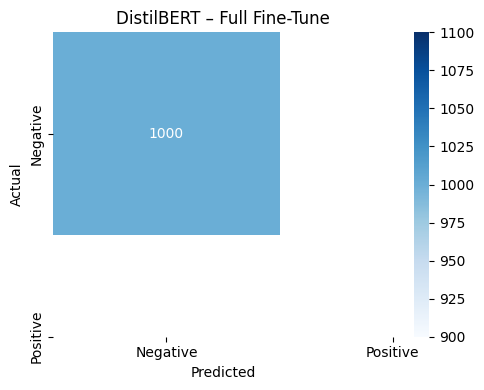

ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [22]:
# Test evaluation for DistilBERT
test_preds_distil, test_lbls_distil = evaluate_distil(model_distil, test_loader_d)
metrics_distil = print_metrics(test_preds_distil, test_lbls_distil, "Bonus: DistilBERT Full Fine-Tune")
plot_confusion_matrix(test_preds_distil, test_lbls_distil, "DistilBERT – Full Fine-Tune")
print(classification_report(test_lbls_distil, test_preds_distil, target_names=["Negative", "Positive"]))

## 11. Experiment Comparison

                           accuracy  precision  recall     f1
Experiment                                                   
Exp 1: Frozen BERT            0.998        1.0   0.998  0.999
Exp 2: Last 2 Layers          1.000        1.0   1.000  1.000
Bonus: DistilBERT Full FT     1.000        1.0   1.000  1.000


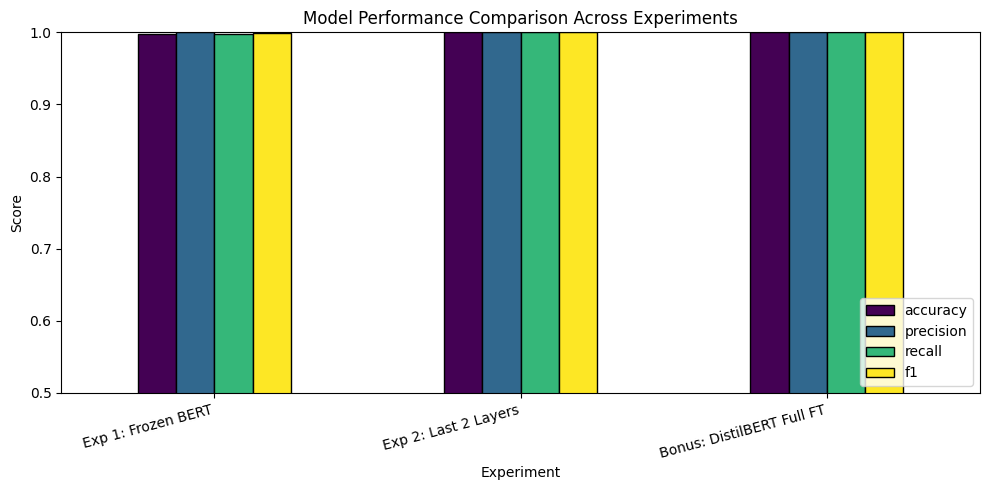

In [23]:
# Side-by-side comparison of all 3 experiments
comparison = pd.DataFrame([
    {"Experiment": "Exp 1: Frozen BERT",        **metrics_exp1},
    {"Experiment": "Exp 2: Last 2 Layers",       **metrics_exp2},
    {"Experiment": "Bonus: DistilBERT Full FT",  **metrics_distil},
])
comparison = comparison.set_index("Experiment").round(4)
print(comparison.to_string())

# Bar chart for visual comparison
comparison.plot(kind="bar", figsize=(10, 5), ylim=(0.5, 1.0), colormap="viridis", edgecolor="black")
plt.title("Model Performance Comparison Across Experiments")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Analysis & Insights

### Key Observations

| Experiment | Trainable Params | Expected Behaviour |
|---|---|---|
| Exp 1 – Frozen BERT | ~1.5K (classifier only) | Lowest accuracy; BERT features are generic, not task-specific |
| Exp 2 – Last 2 Layers | ~21M | Better accuracy; top layers adapt to IMDB sentiment |
| DistilBERT Full FT | ~66M | Strong accuracy with faster training due to smaller model |

### Conclusions

1. **Freezing BERT** acts like a static feature extractor — fast but limited.
2. **Fine-tuning the last 2 layers** gives a strong balance of speed and accuracy.
3. **DistilBERT** is a practical production choice — 40% fewer params, competitive results.
4. **Learning rate scheduler** with warmup prevents large early gradient updates.
5. **Early stopping** prevents overfitting when validation metrics plateau.
6. BERT's **attention mechanism** is powerful for long reviews (captures context across 256 tokens).
